In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from math import ceil
from tensorflow import keras # type: ignore
from tensorflow.keras import layers # type: ignore
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

sns.set_theme()

# Загрузка, нормализация и разбиение данных

In [9]:
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.cifar10.load_data()

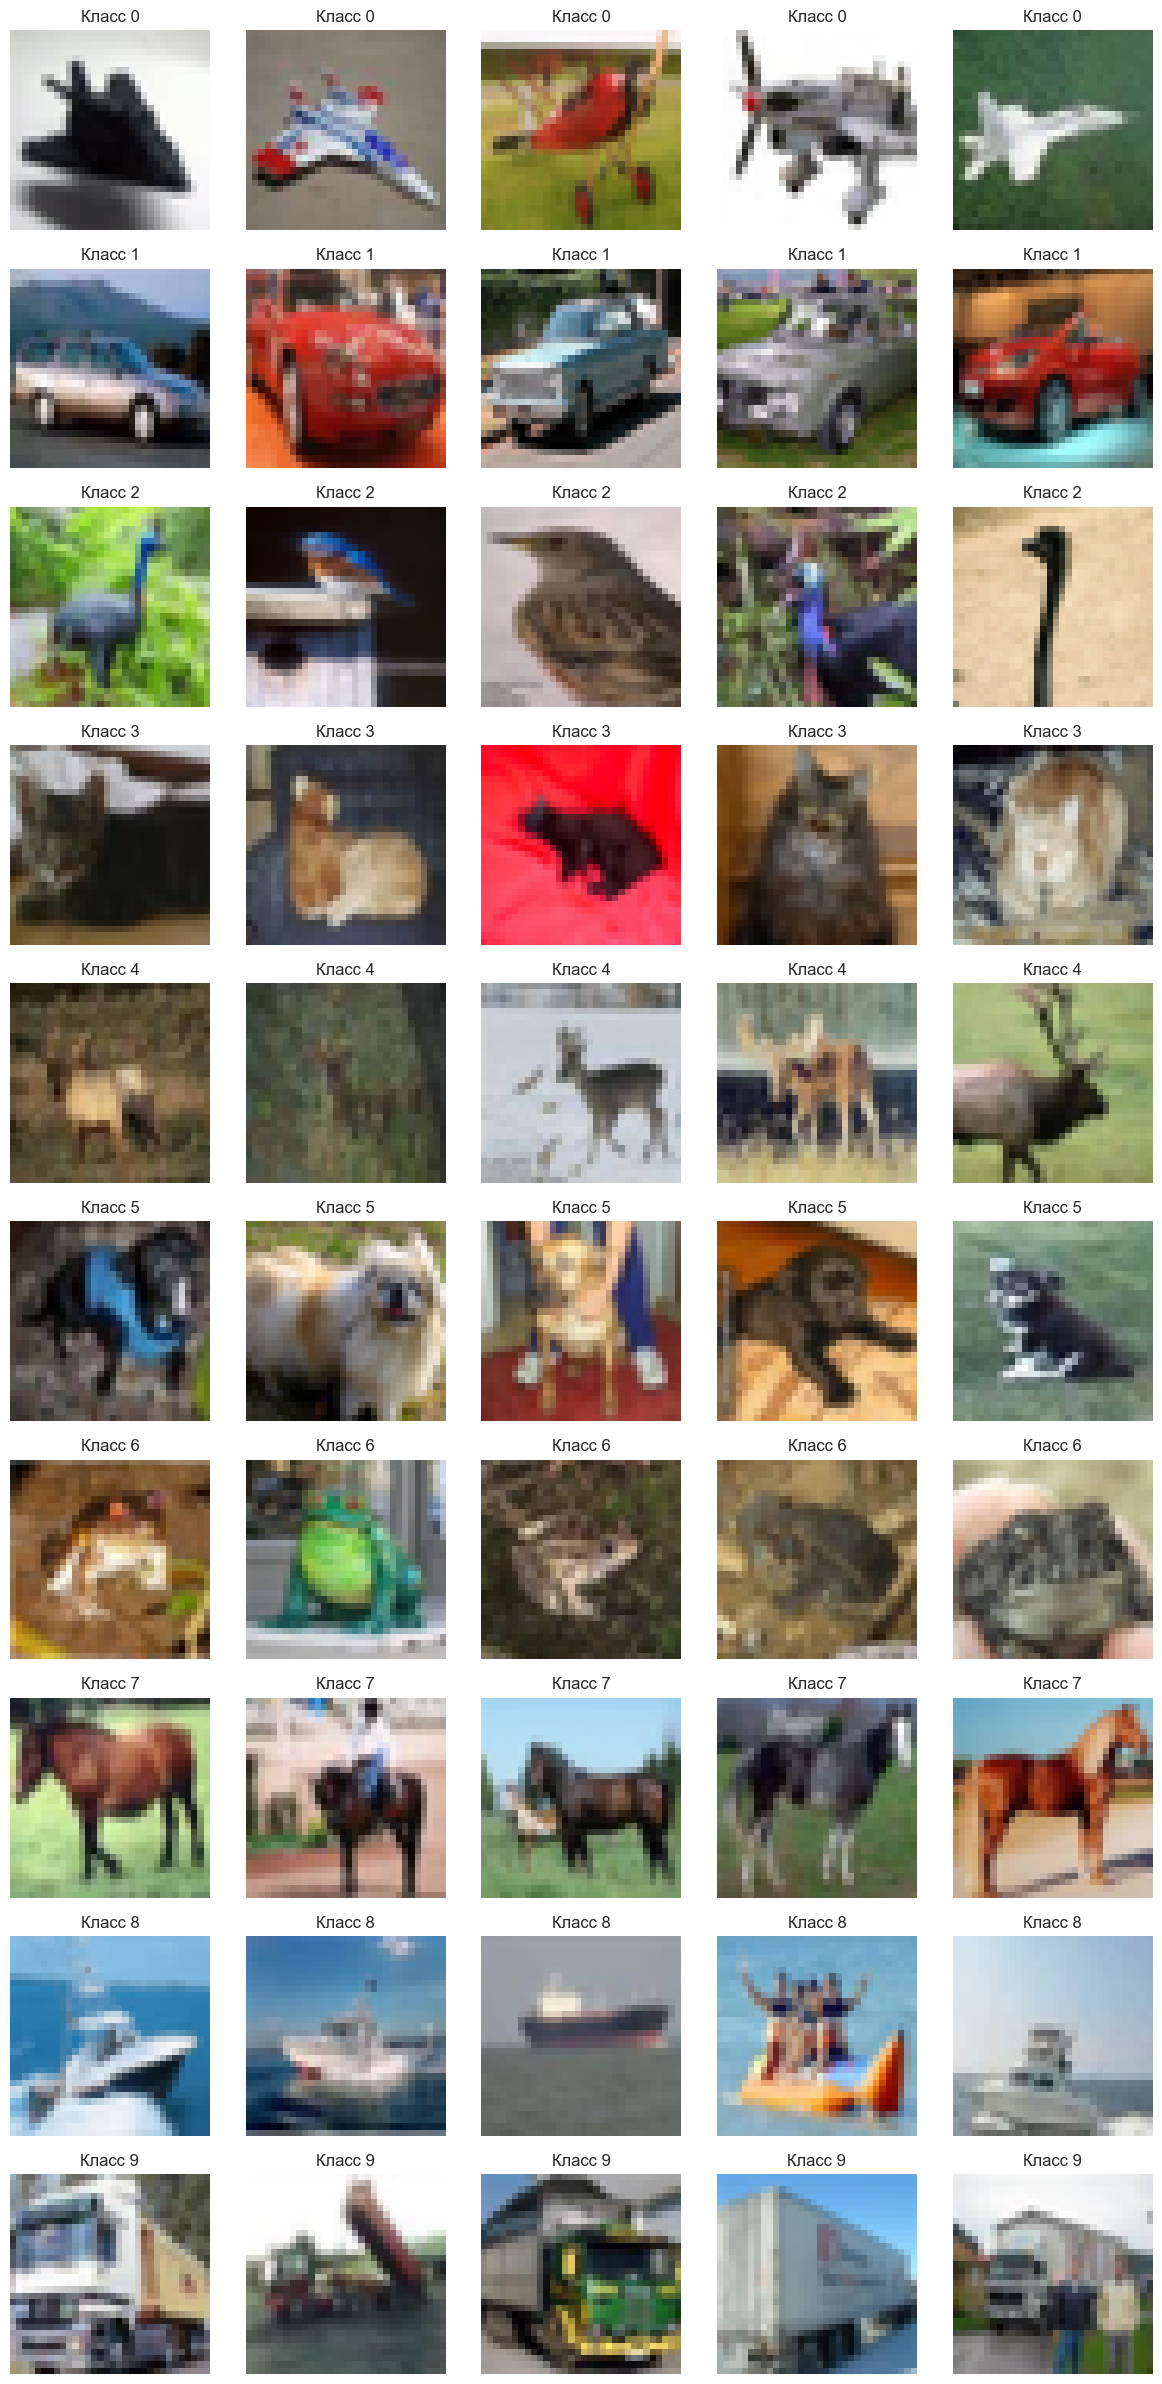

In [10]:
class_indices = {i: [] for i in range(10)}
for index, y in enumerate(y_train_full):
    label = y[0]
    if label in class_indices and len(class_indices[label]) < 5:
        class_indices[label].append(index)
    if all(len(class_indices[i]) == 5 for i in range(10)):
        break

fig, axes = plt.subplots(nrows=10, ncols=5, figsize=(12, 24))
axes = axes.flatten()

ax_index = 0
for label in range(10):
    for image_index in class_indices[label]:
        ax = axes[ax_index]
        ax.axis("off")
        ax.set_title(f"Класс {label}")
        ax.imshow(x_train_full[image_index])
        ax_index += 1

plt.tight_layout()

In [11]:
print(x_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1) (10000, 32, 32, 3) (10000, 1)


In [12]:
train_counts = np.bincount(y_train_full.flatten())
train_percents = (train_counts / len(y_train_full)) * 100

train_stats = pd.DataFrame({
    "Класс": range(10),
    "Количество": train_counts,
    "Доля (%)": train_percents.round(2)
})
train_stats["Доля (%)"] = train_stats["Доля (%)"].astype(str)

test_counts = np.bincount(y_test.flatten())
test_percents = (test_counts / len(y_test)) * 100

test_stats = pd.DataFrame({
    "Класс": range(10),
    "Количество": test_counts,
    "Доля (%)": test_percents.round(2)
})
test_stats["Доля (%)"] = test_stats["Доля (%)"].astype(str)

print("Распределение классов в обучающей выборке:")
display(train_stats.style.hide(axis="index"))

print("Распределение классов в тестовой выборке:")
display(test_stats.style.hide(axis="index"))

Распределение классов в обучающей выборке:


Класс,Количество,Доля (%)
0,5000,10.0
1,5000,10.0
2,5000,10.0
3,5000,10.0
4,5000,10.0
5,5000,10.0
6,5000,10.0
7,5000,10.0
8,5000,10.0
9,5000,10.0


Распределение классов в тестовой выборке:


Класс,Количество,Доля (%)
0,1000,10.0
1,1000,10.0
2,1000,10.0
3,1000,10.0
4,1000,10.0
5,1000,10.0
6,1000,10.0
7,1000,10.0
8,1000,10.0
9,1000,10.0


In [13]:
x_train_full = x_train_full / 255
x_test = x_test / 255

y_train_full = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print(x_train_full.shape, y_train_full.shape, x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 10) (10000, 32, 32, 3) (10000, 10)


In [14]:
x_train, x_valid, y_train, y_valid = train_test_split(
    x_train_full, y_train_full, test_size=0.2, random_state=0
)

print(x_train.shape, x_valid.shape, y_train.shape, y_valid.shape)

(40000, 32, 32, 3) (10000, 32, 32, 3) (40000, 10) (10000, 10)


# Создание и обучение моделей

In [ ]:
input_shape = (32, 32, 3)

model1 = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    
    layers.Dense(10, activation="softmax")
])

model1.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model1.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model2 = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),
    
    layers.Conv2D(64, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),
    
    layers.Conv2D(128, (3, 3), padding="same"),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.1),
    
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.Dropout(0.5),

    layers.Dense(10, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model2.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 622,282 (2.37 MB)

 Trainable params: 621,322 (2.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [39]:
model3 = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model3.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,122 (3.11 MB)

 Trainable params: 814,122 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
batch_size = 256
n_epochs = 15

history1 = model1.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=n_epochs,
    validation_data=(x_valid, y_valid)
)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.3874 - loss: 1.6742 - val_accuracy: 0.4864 - val_loss: 1.3916
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 68ms/step - accuracy: 0.5432 - loss: 1.2827 - val_accuracy: 0.5500 - val_loss: 1.2834
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.6127 - loss: 1.1074 - val_accuracy: 0.6193 - val_loss: 1.0767
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.6536 - loss: 0.9907 - val_accuracy: 0.6695 - val_loss: 0.9603
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.6881 - loss: 0.8991 - val_accuracy: 0.6790 - val_loss: 0.9126
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7189 - loss: 0.8142 - val_accuracy: 0.6974 - val_loss: 0.8713
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7361 - loss: 0.7614 - val_accuracy: 0.7011 - val_loss: 0.8559
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.7578 - loss: 0.7011 - 

In [35]:
history2 = model2.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=n_epochs,
    validation_data=(x_valid, y_valid)
)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 33s 192ms/step - accuracy: 0.4359 - loss: 1.6121 - val_accuracy: 0.1181 - val_loss: 4.1043
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 193ms/step - accuracy: 0.5890 - loss: 1.1546 - val_accuracy: 0.1872 - val_loss: 2.8914
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 191ms/step - accuracy: 0.6507 - loss: 0.9887 - val_accuracy: 0.4709 - val_loss: 1.6054
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 192ms/step - accuracy: 0.6887 - loss: 0.8873 - val_accuracy: 0.5969 - val_loss: 1.1119
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 188ms/step - accuracy: 0.7093 - loss: 0.8239 - val_accuracy: 0.6478 - val_loss: 1.0217
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 31s 200ms/step - accuracy: 0.7313 - loss: 0.7640 - val_accuracy: 0.6920 - val_loss: 0.8935
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 187ms/step - accuracy: 0.7462 - loss: 0.7209 - val_accuracy: 0.7211 - val_loss: 0.7901
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 42s 192ms/step - accuracy: 0.7599 - loss: 0

In [40]:
history3 = model3.fit(
    x_train, y_train,
    batch_size=batch_size,
    epochs=n_epochs,
    validation_data=(x_valid, y_valid)
)

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 192ms/step - accuracy: 0.2649 - loss: 1.9524 - val_accuracy: 0.4156 - val_loss: 1.5859
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 181ms/step - accuracy: 0.4407 - loss: 1.5177 - val_accuracy: 0.5067 - val_loss: 1.3247
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 175ms/step - accuracy: 0.5174 - loss: 1.3202 - val_accuracy: 0.5774 - val_loss: 1.1930
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 175ms/step - accuracy: 0.5664 - loss: 1.2016 - val_accuracy: 0.6238 - val_loss: 1.0559
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 186ms/step - accuracy: 0.6115 - loss: 1.0911 - val_accuracy: 0.6526 - val_loss: 0.9749
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 174ms/step - accuracy: 0.6419 - loss: 1.0148 - val_accuracy: 0.6662 - val_loss: 0.9484
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 28s 176ms/step - accuracy: 0.6650 - loss: 0.9496 - val_accuracy: 0.7013 - val_loss: 0.8525
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 29s 183ms/step - accuracy: 0.6901 - loss: 0

# Тестирование и оценка качества моделей

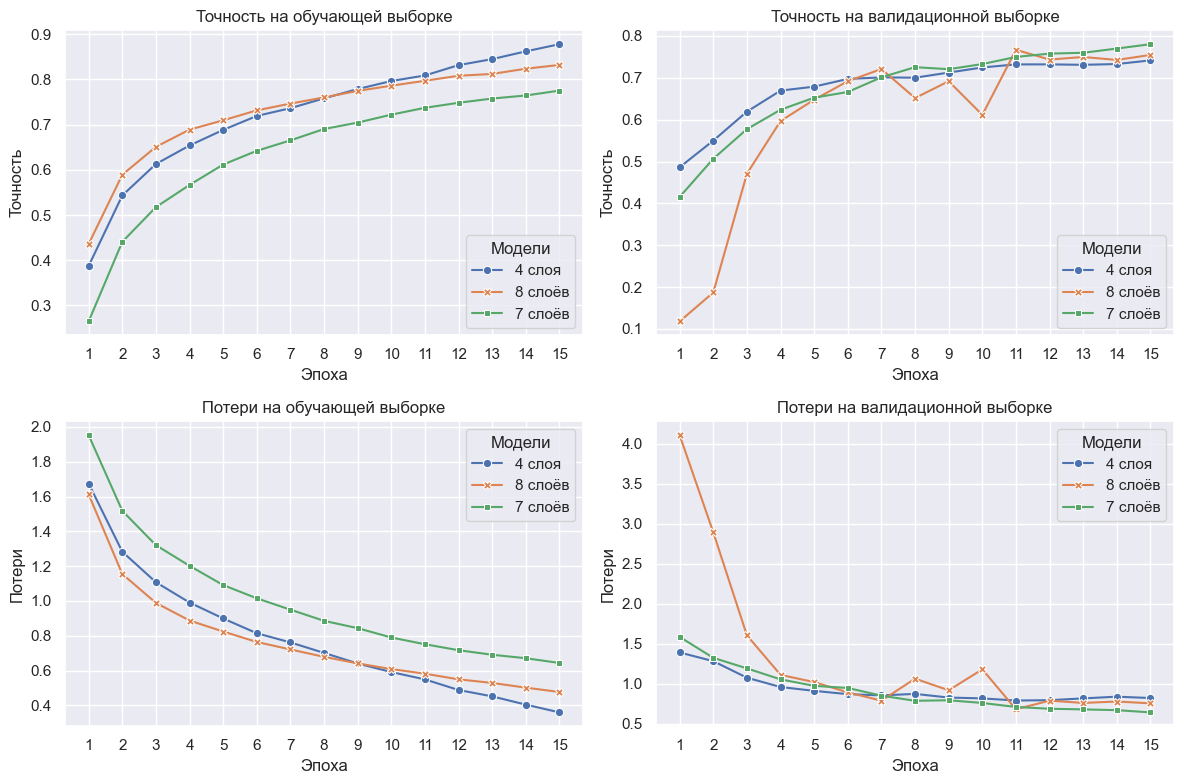

In [45]:
model_names = ["4 слоя", "8 слоёв", "7 слоёв"]

records_list = []

for history, model in zip([history1, history2, history3], model_names):
    for epoch, (train_acc, valid_acc, train_loss, valid_loss) in enumerate(zip(
        history.history["accuracy"],
        history.history["val_accuracy"],
        history.history["loss"],
        history.history["val_loss"]
    )):
        records_list.append({
            "model": model,
            "epoch": epoch + 1,
            "train_acc": train_acc,
            "valid_acc": valid_acc,
            "train_loss": train_loss,
            "valid_loss": valid_loss
        })

records = pd.DataFrame(records_list)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
axes = axes.flatten()

sns.lineplot(
    data=records, x="epoch", y="train_acc", hue="model",
    style="model", dashes=False, markers=True, ax=axes[0]
).set(
    title="Точность на обучающей выборке",
    xlabel="Эпоха", ylabel="Точность", xticks=range(1, n_epochs + 1)
)
axes[0].legend(title="Модели", loc="lower right")

sns.lineplot(
    data=records, x="epoch", y="valid_acc", hue="model",
    style="model", dashes=False, markers=True, ax=axes[1]
).set(
    title="Точность на валидационной выборке",
    xlabel="Эпоха", ylabel="Точность", xticks=range(1, n_epochs + 1)
)
axes[1].legend(title="Модели", loc="lower right")

sns.lineplot(
    data=records, x="epoch", y="train_loss", hue="model",
    style="model", dashes=False, markers=True, ax=axes[2]
).set(
    title="Потери на обучающей выборке",
    xlabel="Эпоха", ylabel="Потери", xticks=range(1, n_epochs + 1)
)
axes[2].legend(title="Модели", loc="upper right")

sns.lineplot(
    data=records, x="epoch", y="valid_loss", hue="model",
    style="model", dashes=False, markers=True, ax=axes[3]
).set(
    title="Потери на валидационной выборке",
    xlabel="Эпоха", ylabel="Потери", xticks=range(1, n_epochs + 1)
)
axes[3].legend(title="Модели", loc="upper right")

plt.tight_layout()

In [46]:
test_loss_1, test_acc_1 = model1.evaluate(x_test, y_test, verbose=0)
test_loss_2, test_acc_2 = model2.evaluate(x_test, y_test, verbose=0)
test_loss_3, test_acc_3 = model3.evaluate(x_test, y_test, verbose=0)

results = pd.DataFrame({
    "model": model_names,
    "params_count": [
        model1.count_params(),
        model2.count_params(),
        model3.count_params(),
    ],
    "train_accuracy": [
        history1.history["accuracy"][-1],
        history2.history["accuracy"][-1],
        history3.history["accuracy"][-1],
    ],
    "train_loss": [
        history1.history["loss"][-1],
        history2.history["loss"][-1],
        history3.history["loss"][-1],
    ],
    "valid_accuracy": [
        history1.history["val_accuracy"][-1],
        history2.history["val_accuracy"][-1],
        history3.history["val_accuracy"][-1],
    ],
    "valid_loss": [
        history1.history["val_loss"][-1],
        history2.history["val_loss"][-1],
        history3.history["val_loss"][-1],
    ],
    "test_accuracy": [test_acc_1, test_acc_2, test_acc_3],
    "test_loss": [test_loss_1, test_loss_2, test_loss_3]
})

display(results.style.hide(axis="index"))

model,params_count,train_accuracy,train_loss,valid_accuracy,valid_loss,test_accuracy,test_loss
4 слоя,620362,0.877525,0.359295,0.741700,0.822972,0.738300,0.855715
8 слоёв,622282,0.831675,0.476548,0.754700,0.756877,0.748600,0.761337
7 слоёв,814122,0.774950,0.643328,0.780400,0.643658,0.777000,0.651095


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


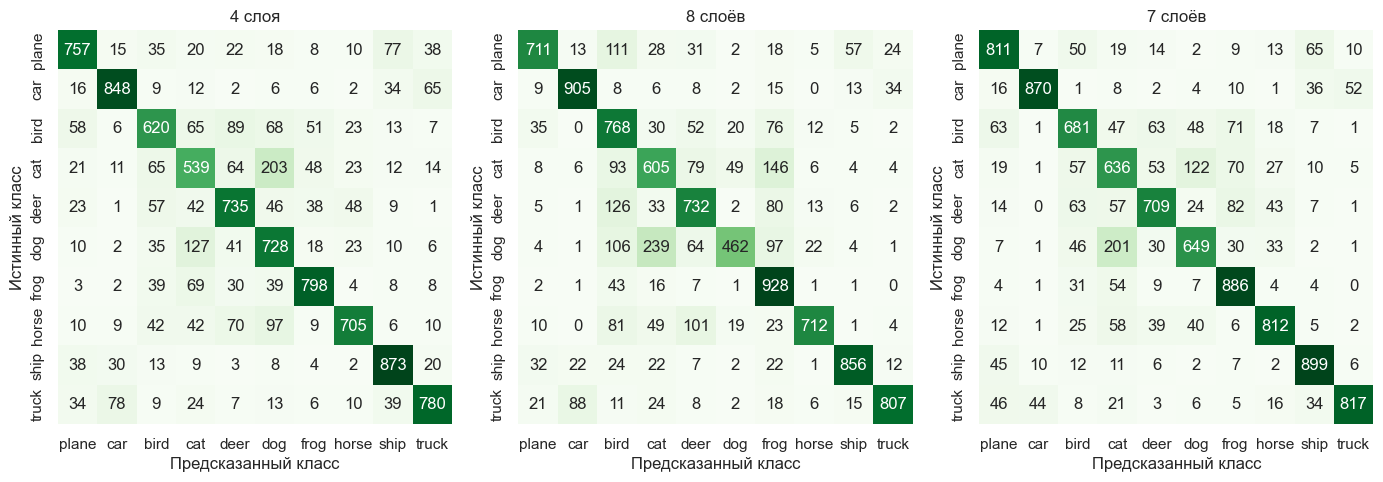

In [59]:
class_names = np.array([
    "plane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
])

y_true = np.argmax(y_test, axis=1)

y_pred_proba_1 = model1.predict(x_test)
y_pred_proba_2 = model2.predict(x_test)
y_pred_proba_3 = model3.predict(x_test)

y_pred_1 = np.argmax(y_pred_proba_1, axis=1)
y_pred_2 = np.argmax(y_pred_proba_2, axis=1)
y_pred_3 = np.argmax(y_pred_proba_3, axis=1)

cm1 = confusion_matrix(y_true, y_pred_1)
cm2 = confusion_matrix(y_true, y_pred_2)
cm3 = confusion_matrix(y_true, y_pred_3)

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(14, 6))

for ax, cm, title in zip(axes, [cm1, cm2, cm3], model_names):
    sns.heatmap(
        cm, cmap="Greens", annot=True, fmt="d", cbar=False, square=True, ax=ax
    ).set(
        title=title, xlabel="Предсказанный класс", ylabel="Истинный класс",
        xticklabels=class_names, yticklabels=class_names
    )

plt.tight_layout()

Всего 127 изображений, где класс 'plane' принят за 'ship'


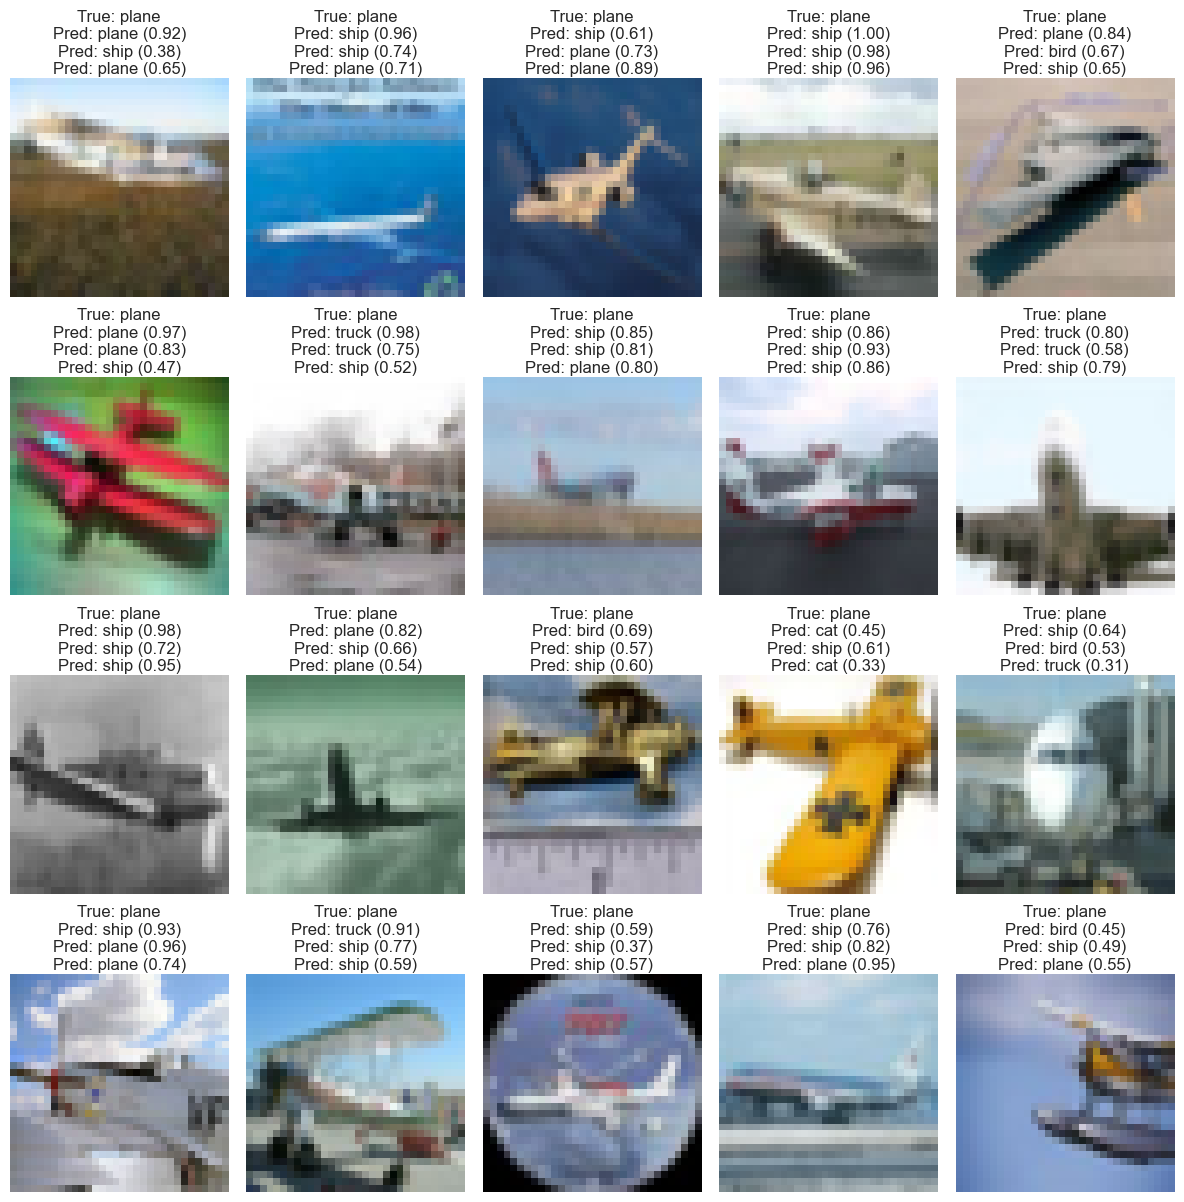

In [77]:
y_true_names = class_names[y_true]
y_pred_names_1 = class_names[y_pred_1]
y_pred_names_2 = class_names[y_pred_2]
y_pred_names_3 = class_names[y_pred_3]


def get_error_indices(true, pred):
    error_indices = []

    for i in np.where(y_true_names == true)[0]:
        if (y_pred_names_1[i] == pred or y_pred_names_2[i] == pred or y_pred_names_3[i] == pred):
            error_indices.append(i)

    print(f"Всего {len(error_indices)} изображений, где класс '{true}' принят за '{pred}'")
    
    return error_indices


def plot_errors(error_indices, n_samples):
    n_cols = 5
    n_rows = ceil(len(error_indices[:n_samples]) / n_cols)

    _, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 3))
    axes = axes.flatten()

    for ax, error_index in zip(axes, error_indices[:n_samples]):
        pred1 = y_pred_1[error_index]
        pred2 = y_pred_2[error_index]
        pred3 = y_pred_3[error_index]

        prob1 = y_pred_proba_1[error_index][pred1]
        prob2 = y_pred_proba_2[error_index][pred2]
        prob3 = y_pred_proba_3[error_index][pred3]
        
        ax.axis("off")
        ax.set_title(
            f"True: {y_true_names[error_index]}\n"
            f"Pred: {y_pred_names_1[error_index]} ({prob1:.2f})\n"
            f"Pred: {y_pred_names_2[error_index]} ({prob2:.2f})\n"
            f"Pred: {y_pred_names_3[error_index]} ({prob3:.2f})",
            pad=3
        )
        ax.imshow(x_test[error_index], cmap="gray_r")

    for ax in axes[len(error_indices[:n_samples]):]:
        ax.axis("off")

    plt.tight_layout(h_pad=3)


plot_errors(get_error_indices(true="plane", pred="ship"), n_samples=20)

Всего 82 изображений, где класс 'ship' принят за 'plane'


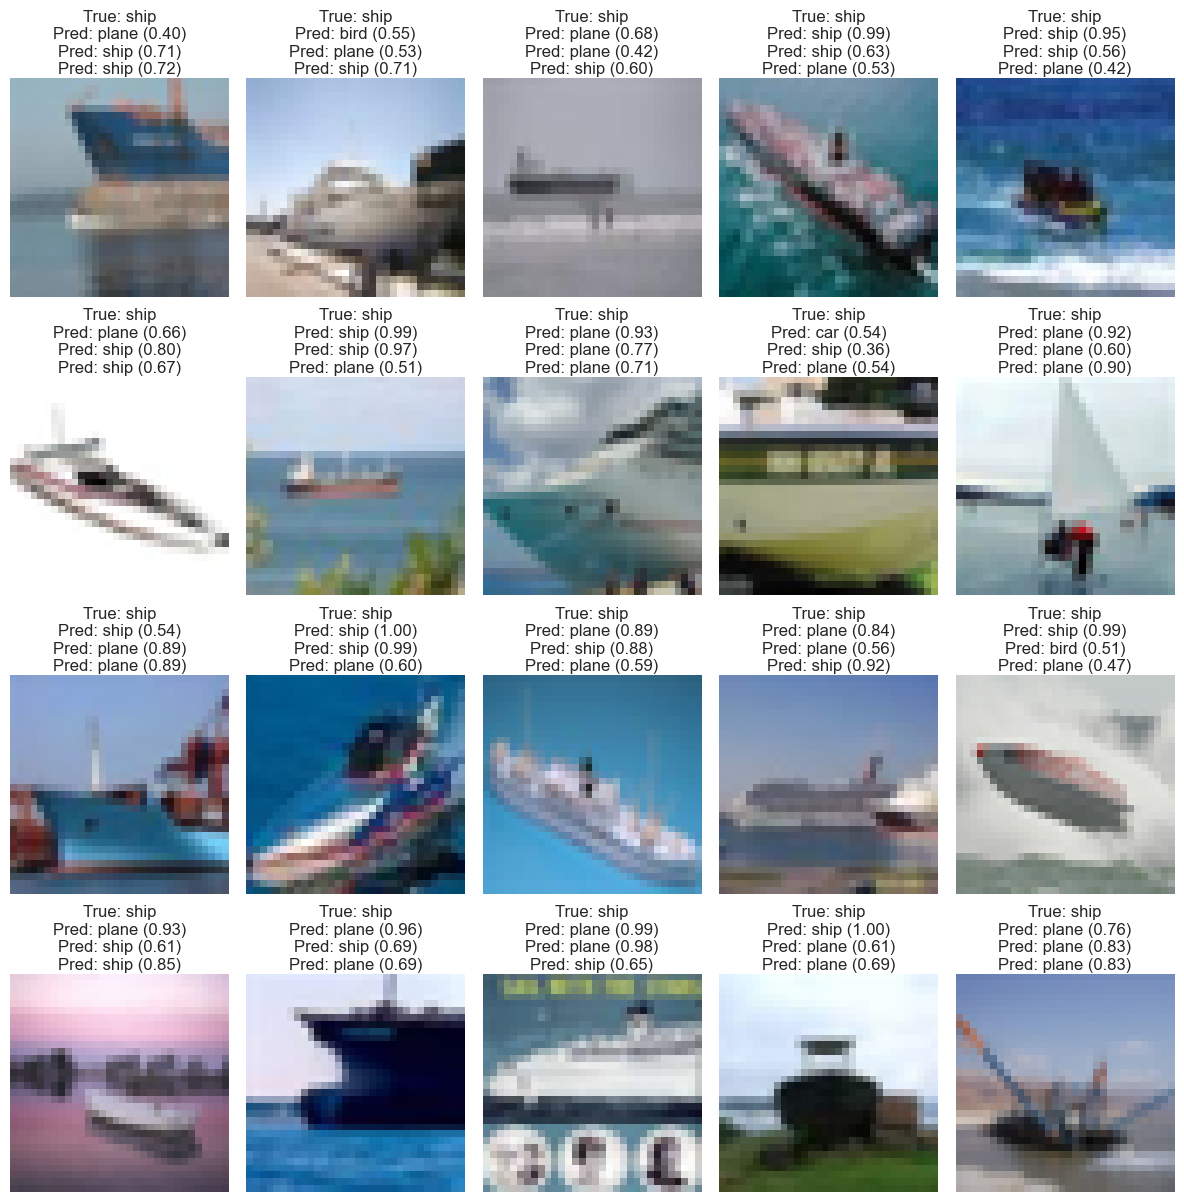

In [85]:
plot_errors(get_error_indices(true="ship", pred="plane"), n_samples=20)

Всего 99 изображений, где класс 'car' принят за 'truck'


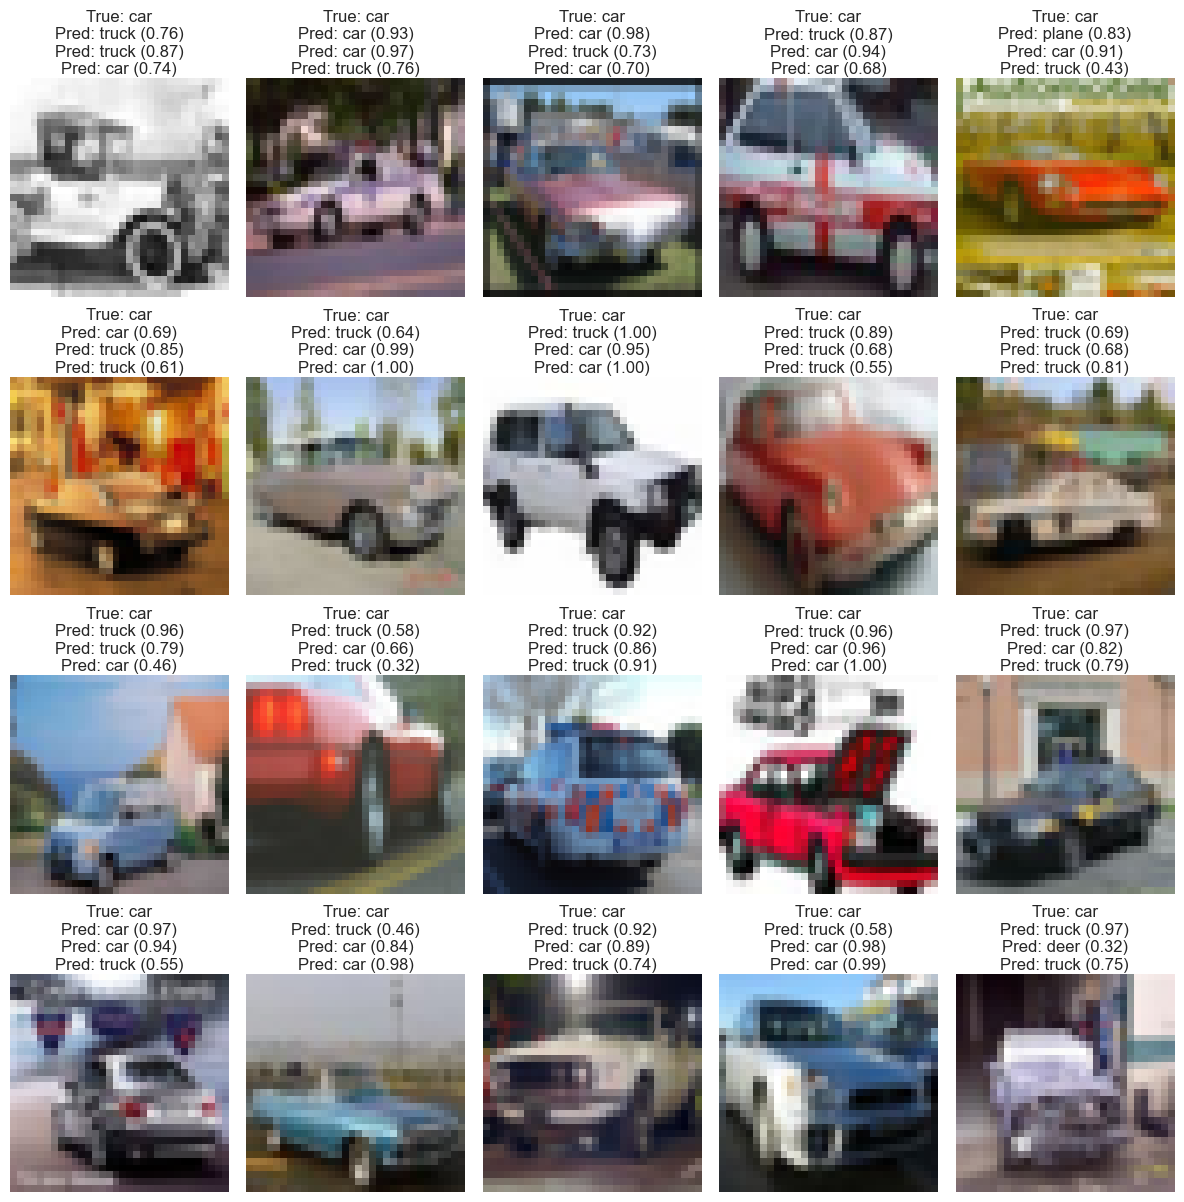

In [86]:
plot_errors(get_error_indices(true="car", pred="truck"), n_samples=20)

Всего 135 изображений, где класс 'truck' принят за 'car'


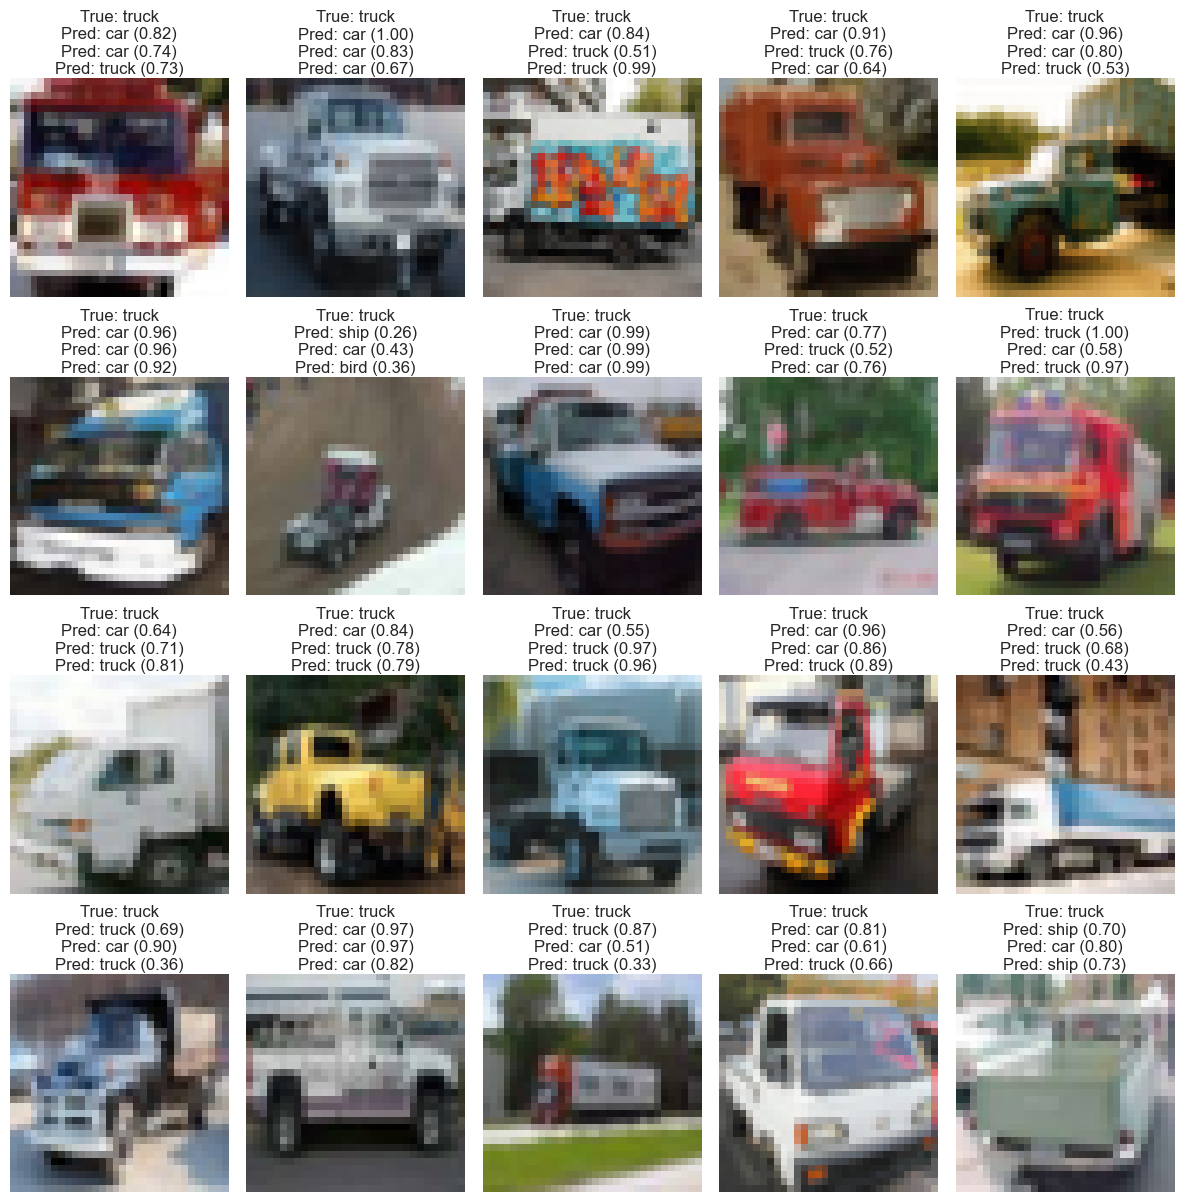

In [87]:
plot_errors(get_error_indices(true="truck", pred="car"), n_samples=20)

Всего 263 изображений, где класс 'cat' принят за 'dog'


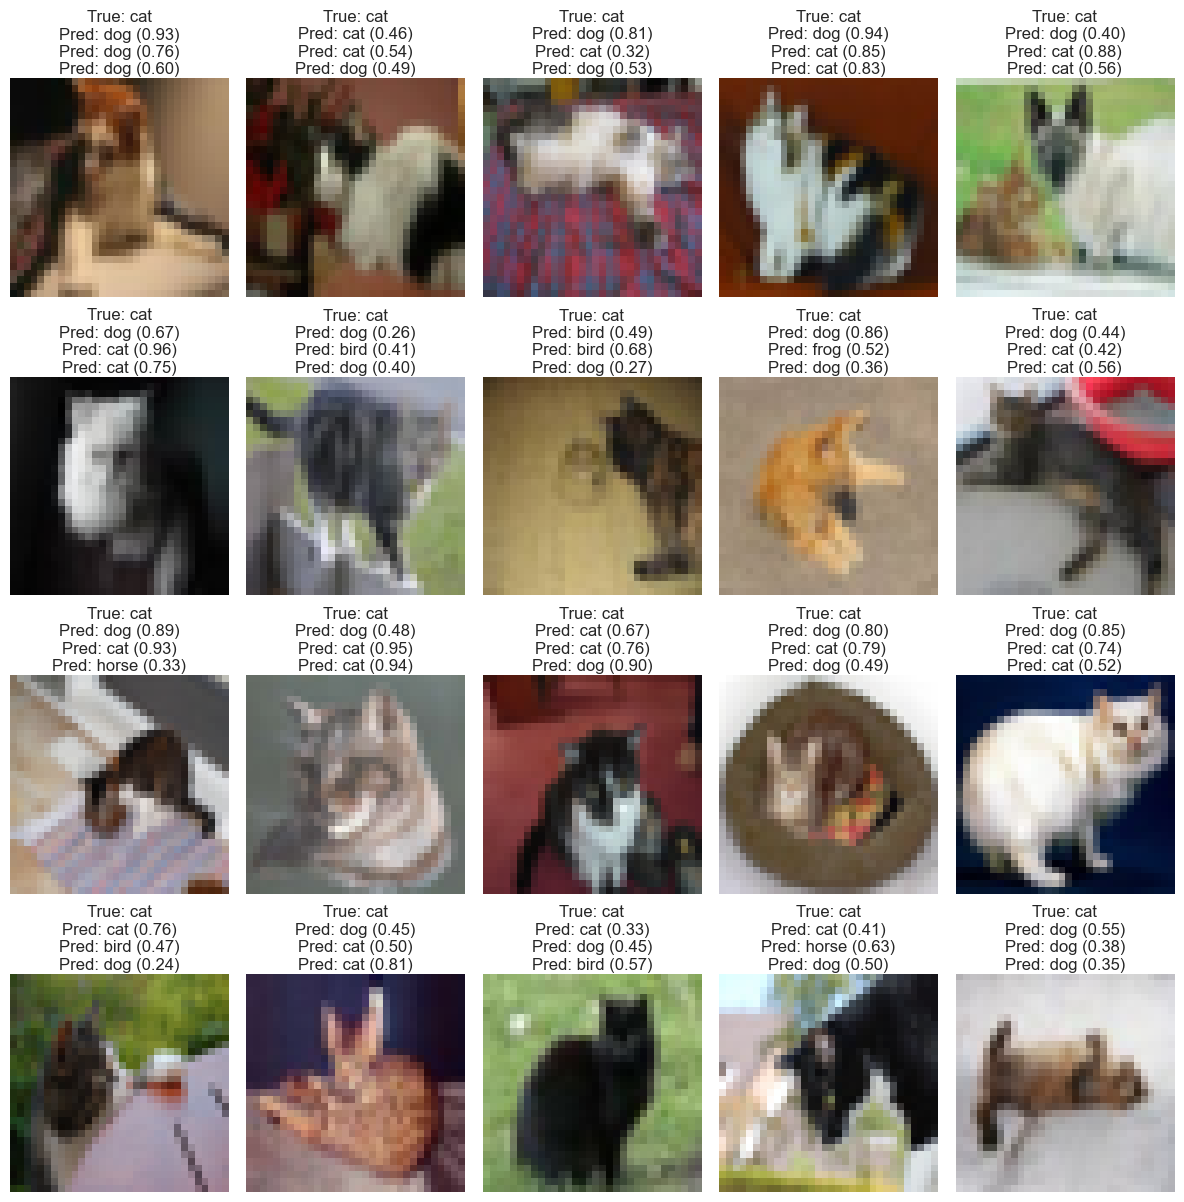

In [88]:
plot_errors(get_error_indices(true="cat", pred="dog"), n_samples=20)

Всего 350 изображений, где класс 'dog' принят за 'cat'


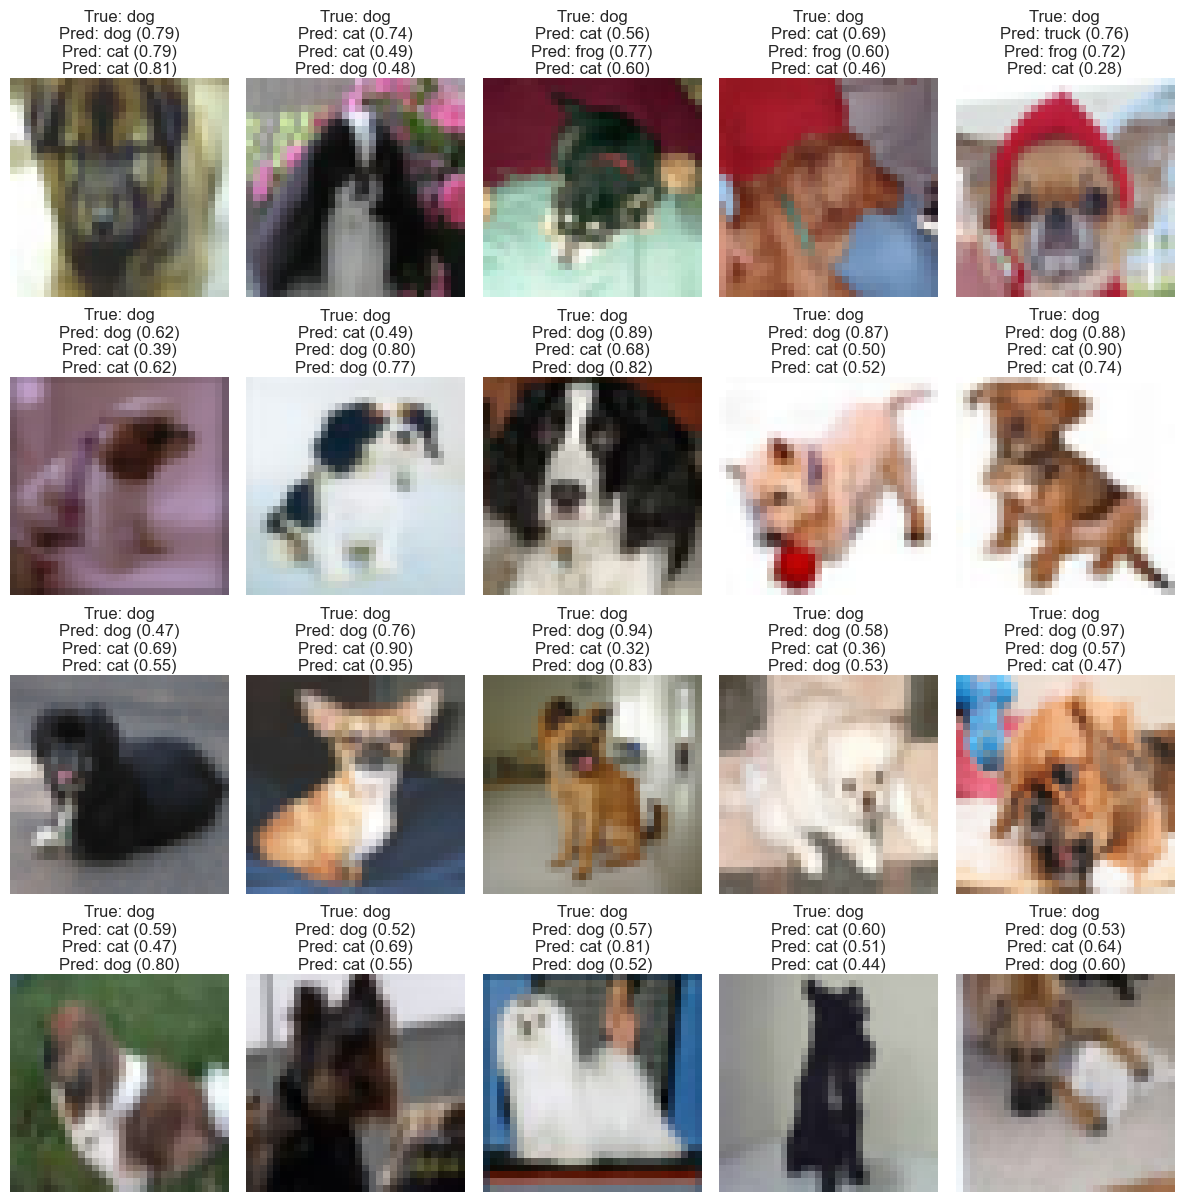

In [89]:
plot_errors(get_error_indices(true="dog", pred="cat"), n_samples=20)

Всего 76 изображений, где класс 'frog' принят за 'bird'


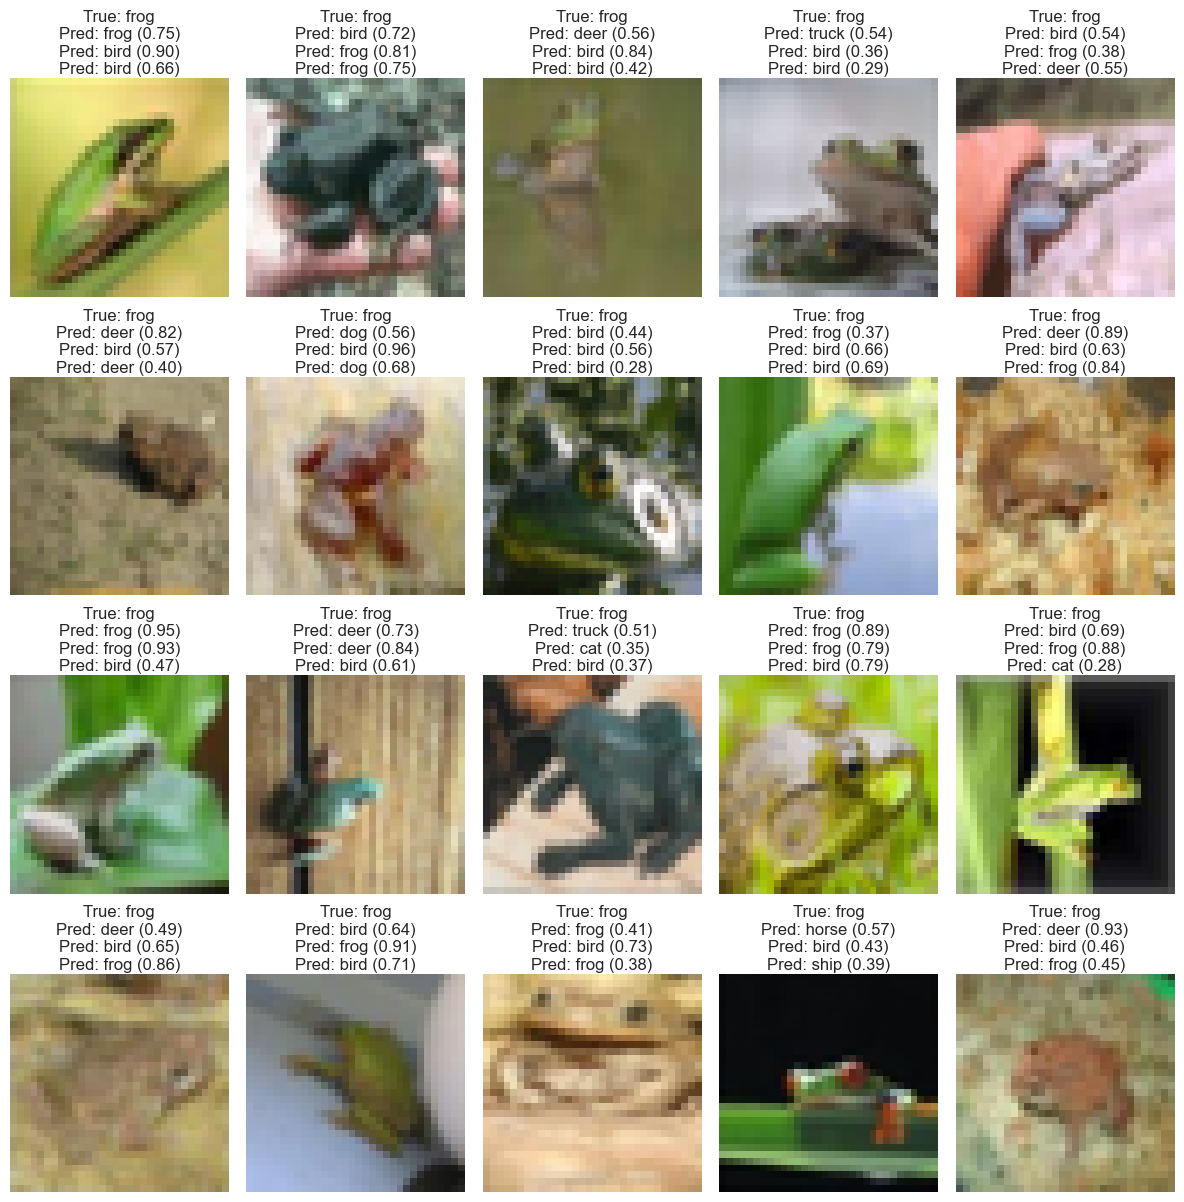

In [90]:
plot_errors(get_error_indices(true="frog", pred="bird"), n_samples=20)

Всего 128 изображений, где класс 'bird' принят за 'deer'


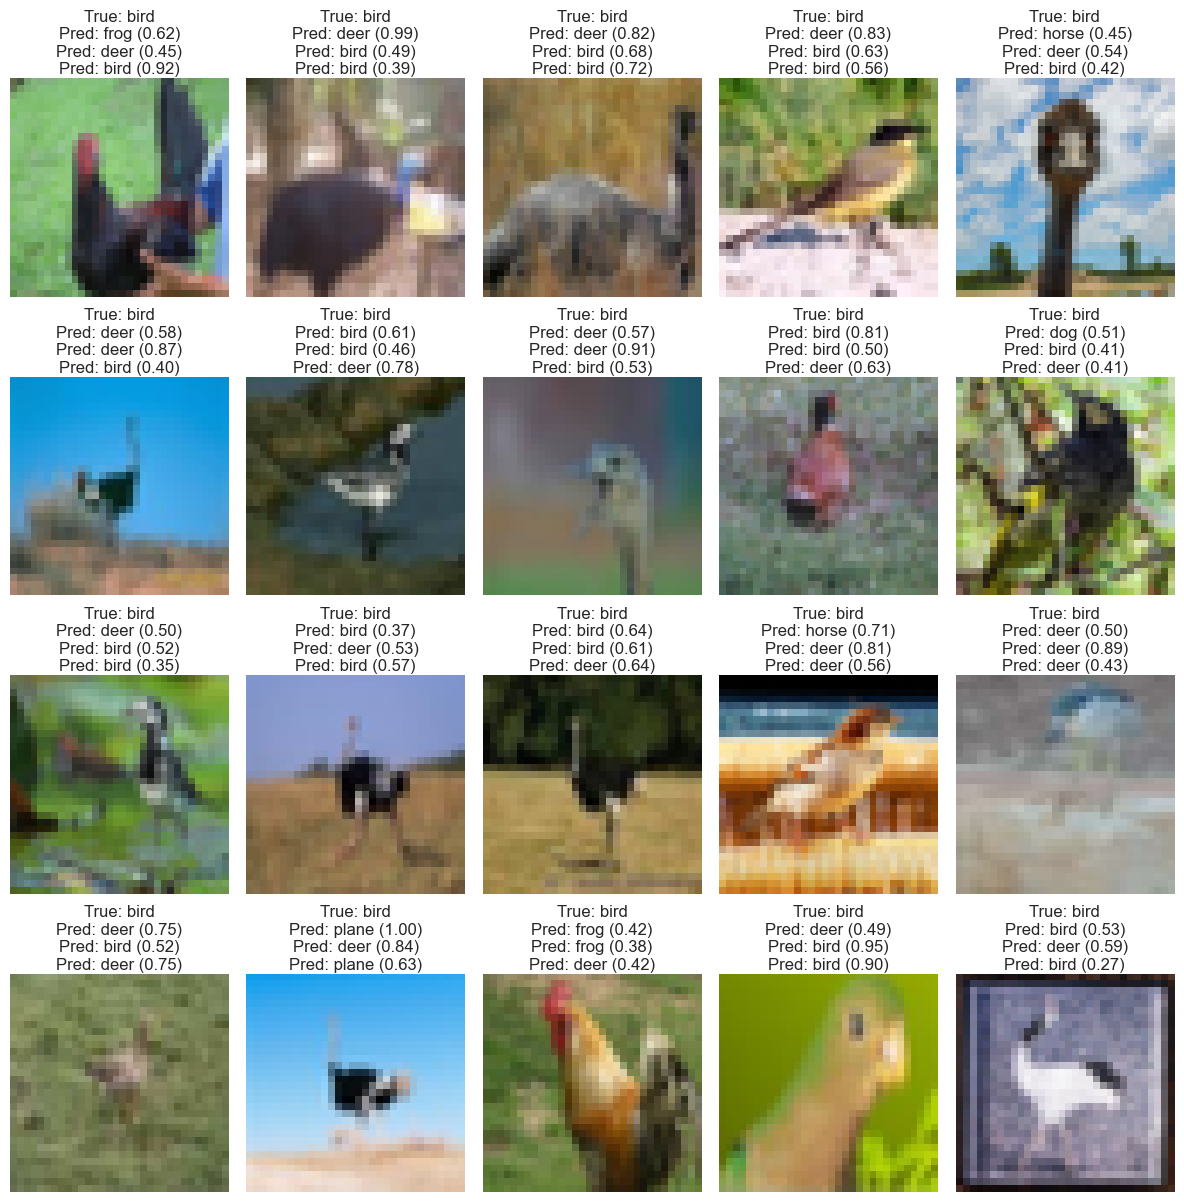

In [91]:
plot_errors(get_error_indices(true="bird", pred="deer"), n_samples=20)

Всего 130 изображений, где класс 'deer' принят за 'frog'


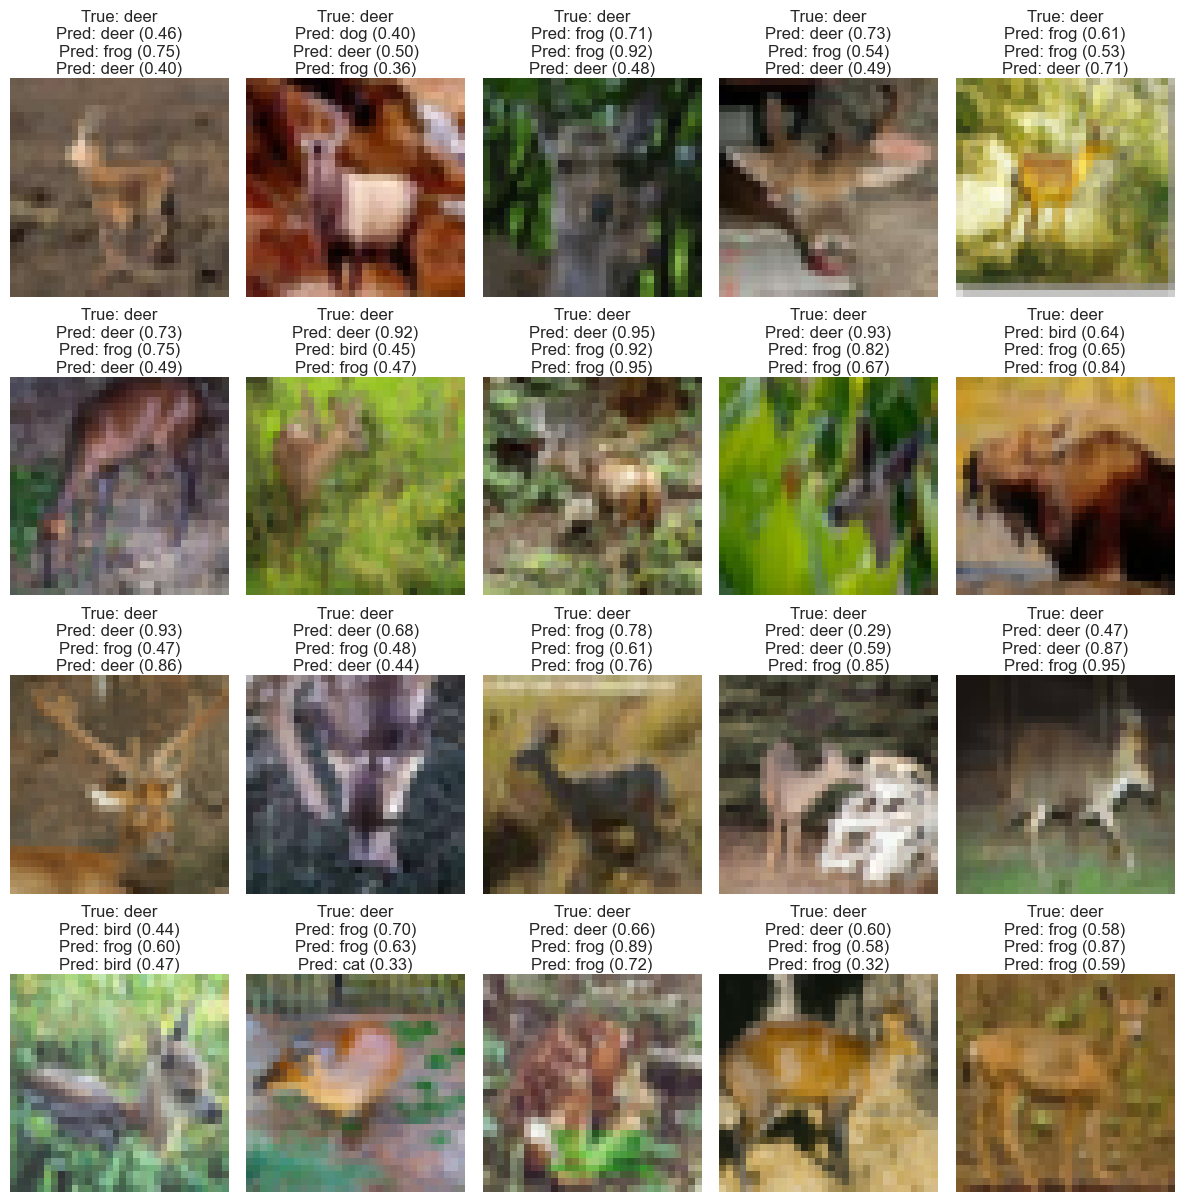

In [92]:
plot_errors(get_error_indices(true="deer", pred="frog"), n_samples=20)

Всего 142 изображений, где класс 'horse' принят за 'deer'


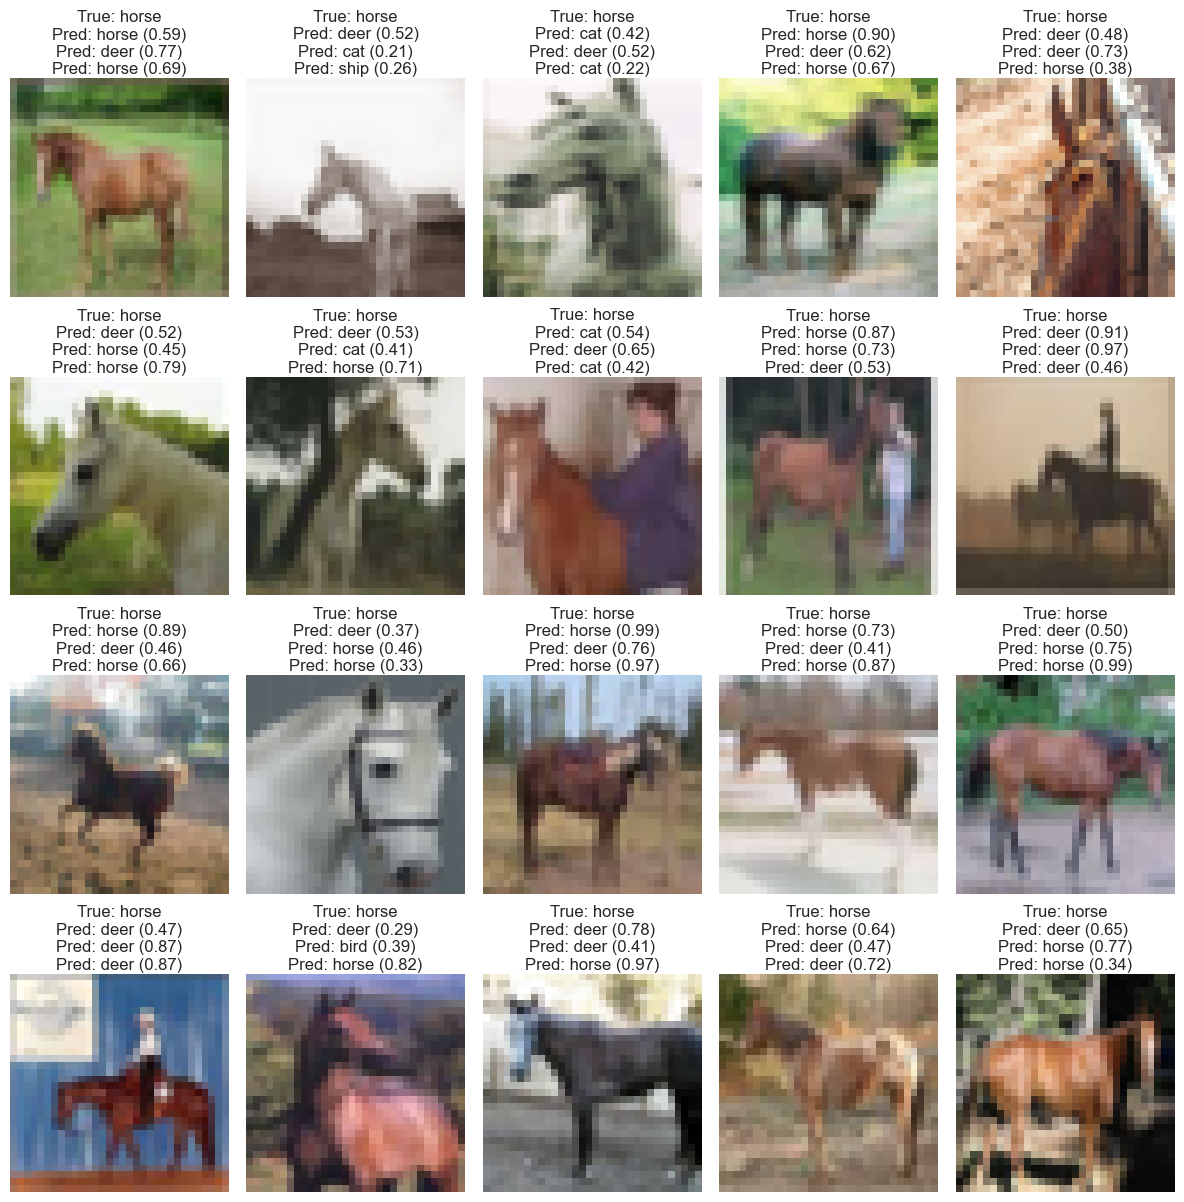

In [93]:
plot_errors(get_error_indices(true="horse", pred="deer"), n_samples=20)